###### 自然言語処理...私達の言語をコンピュータに理解させるための技術
###### → 意味の最小単位である「単語の意味」を理解させる
######
###### 単語の意味を捉える方法
###### ・シソーラス
###### ・カウントベース
###### ・推論ベース

####
#### 2.2 シソーラス
######
###### 人の手で単語の意味を定義し、類語辞書を作る
###### 同義語や類義語を同じグループに分類し、
###### 単語間で「上位（全体）」と「下位（部分）」などの細かい関連性を定義する。
###### ex) WordNet
######
###### 問題点
###### ・時代の変化に対応するのが困難
###### ・人の作業コストが高い
###### ・単語の細かなニュアンスを表現できない
###### → 大量のテキストデータから自動的に「単語の意味」を抽出する手法へ

####
#### 2.3 カウントベースの手法（統計的手法）
###### ある単語に着目した場合に、その周囲にどのような単語がどれだけ現れるのかをカウントし、それを集計することで、単語をベクトルで表す。
######
###### コーパス...（研究やアプリのために目的を持って収集された）大量のテキストデータ

In [17]:
# 前処理：テキストデータ（コーパス）を単語に分割
text = 'You say goodbye and I say hello.'

In [19]:
text = text.lower()
text = text.replace('.',' .')
text

'you say goodbye and i say hello .'

In [21]:
words = text.split()
words

['you', 'say', 'goodbye', 'and', 'i', 'say', 'hello', '.']

In [23]:
# IDのリストとして利用できるように
word_to_id = {}
id_to_word = {}

for word in words:
    if word not in word_to_id:
        new_id = len(word_to_id)
        word_to_id[word] = new_id
        id_to_word[new_id] = word

In [25]:
id_to_word

{0: 'you', 1: 'say', 2: 'goodbye', 3: 'and', 4: 'i', 5: 'hello', 6: '.'}

In [27]:
word_to_id

{'you': 0, 'say': 1, 'goodbye': 2, 'and': 3, 'i': 4, 'hello': 5, '.': 6}

In [29]:
id_to_word[1]

'say'

In [31]:
word_to_id['hello']

5

In [33]:
# 「単語のリスト」を「単語IDのリスト」に変換
import numpy as np
corpus = [word_to_id[w] for w in words]
corpus = np.array(corpus)
corpus

array([0, 1, 2, 3, 4, 1, 5, 6])

In [37]:
# これまでの処理を関数preprocessとしてまとめる
# common/util.py
# 使い方：
# >>> test = 'You say goodbye and I say hello.'
# >>> corpus, word_to_id, id_to_word = preprocess(text)

######
###### 単語の分散表現...「単語の意味」をとらえたベクトル表現
###### → どのように分散表現を構築するか？
######
###### 分布仮説「単語の意味は周囲の単語によって形成される」に基づいているものが多い。
###### ・コンテキスト：ある中央の単語に対して、その周囲にある単語
###### ・ウィンドウサイズ：周囲の単語をどれだけ含めるか　　　と表すこととする

######
###### ウィンドウサイズを１とする
###### 各単語のコンテキストに含まれる単語の頻度をテーブルで表す
|         | you | say | goodbye | and | i | hello | . |
|---------|-----|-----|---------|-----|---|-------|---|
| you     | 0   | 1   |    0    | 0   | 0 |  0    | 0 |
| say     | 1   | 0   |    1    | 0   | 1 |  1    | 0 |
| goodbye | 0   | 1   |  0      | 1   | 0 |  0    | 0 |
| and     | 0   | 0   |  1      | 0   | 1 |  0    | 0 |
| i       | 0   | 1   |  0      | 1   | 0 |  0    | 0 |
| hello   | 0   | 1   |  0      | 0   | 0 |  0    | 1 |
| .       | 0   | 0   |  0      | 0   | 0 |  1    | 0 |
###### このテーブルを共起行列と呼ぶ

In [61]:
C = np.array([
    [0,1,0,0,0,0,0],
    [1,0,1,0,1,1,0],
    [0,1,0,1,0,0,0],
    [0,0,1,0,1,0,0],
    [0,1,0,1,0,0,0],
    [0,1,0,0,0,0,1],
    [0,0,0,0,0,1,0],
], dtype=np.int32)

In [63]:
print(C[0]) #単語IDが0のベクトル

[0 1 0 0 0 0 0]


In [67]:
print(C[word_to_id['goodbye']]) #goodbyeのベクトル

[0 1 0 1 0 0 0]


In [69]:
# コーパスから共起行列を作る関数 create_co_matrix
# common/util.py

In [ ]:
# コサイン類似度
# 0除算の発生を防ぐため、小さな値を加算する
def cos_similarity(x, y, eps=1e-8):
    nx = x/(np.sqrt(np.sum(x**2))+eps)
    ny = y/(np.sqrt(np.sum(y**2))+eps)
    return np.dot(nx, ny)

In [75]:
x = np.array([100, -20, 2])
x.argsort() #小さい順にソート

array([1, 2, 0])

In [79]:
# 大きい順にソート
(-x).argsort()

array([0, 2, 1])

In [ ]:
(base) sanonanari@snnnrnoMacBook-Air deep-learning-from-scratch-2 % python ch02/most_similar.py

[query] you
 goodbye: 0.7071067691154799
 i: 0.7071067691154799
 hello: 0.7071067691154799
 say: 0.0
 and: 0.0

######
###### 相互情報量(PMI)...高頻度語が見かけ上の強い関連性を持つように評価されてしまう問題を補正した指標
###### $$PMI(x, y) = \log_2\left(\frac{P(x, y)}{P(x)  P(y)}\right) = \log_2\left(\frac{C(x, y)・N}{C(x) C(y)}\right)$$
###### $$P(x) : 単語xがコーパスに現れる確率　　　P(x,y): 単語xとyが共起する確率$$
###### $$C : 共起行列　　　C(x) : 単語xの出現回数　　　N : コーパスに含まれる単語数$$

###### 2つの単語の共起する回数が0のとき
###### $\log_2{0} = -∞$ となってしまうのを避けるため、実践上では正の相互情報量(PPMI)を用いる
###### $$PPMI(x,y) = max(0,PMI(x,y))$$

In [ ]:
# 共起行列をPPMI行列に変換
(base) sanonanari@snnnrnoMacBook-Air deep-learning-from-scratch-2 % python ch02/ppmi.py        
co-occurrence matrix
[[0 1 0 0 0 0 0]
 [1 0 1 0 1 1 0]
 [0 1 0 1 0 0 0]
 [0 0 1 0 1 0 0]
 [0 1 0 1 0 0 0]
 [0 1 0 0 0 0 1]
 [0 0 0 0 0 1 0]]
--------------------------------------------------
PPMI
[[0.    1.807 0.    0.    0.    0.    0.   ]
 [1.807 0.    0.807 0.    0.807 0.807 0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.    1.807 0.    1.807 0.    0.   ]
 [0.    0.807 0.    1.807 0.    0.    0.   ]
 [0.    0.807 0.    0.    0.    0.    2.807]
 [0.    0.    0.    0.    0.    2.807 0.   ]]

######
###### PPMI行列の問題点：
###### ・コーパスの語彙数が増えるにつれて各単語のベクトルの次元数も増えるため、莫大な数になる
###### ・行列の多くの要素は0で重要度が低い
###### → ベクトルの次元削減

###### 次元削減...重要な情報をできるだけ残した上で削減する

In [ ]:
# SVDによる次元削減
(base) sanonanari@snnnrnoMacBook-Air deep-learning-from-scratch-2 % python ch02/count_method_small.py   
[0 1 0 0 0 0 0] #共起行列
[0.    1.807 0.    0.    0.    0.    0.   ] #PPMI行列
[ 0.000e+00  3.409e-01 -3.886e-16 -1.205e-01  9.323e-01 -1.110e-16 #SVD
 -1.467e-16]

In [126]:
# 2次元のベクトルを取り出す : 先頭の2つの要素を取り出す
U = np.array([[0.000e+00, 3.409e-01, -3.886e-16, -1.205e-01, 9.323e-01, -1.110e-16, -1.467e-16]])
print(U[0,:2])

[0.     0.3409]


###### 共起行列に対してSVDを行い、各単語を2次元ベクトルにしてグラフにプロットする
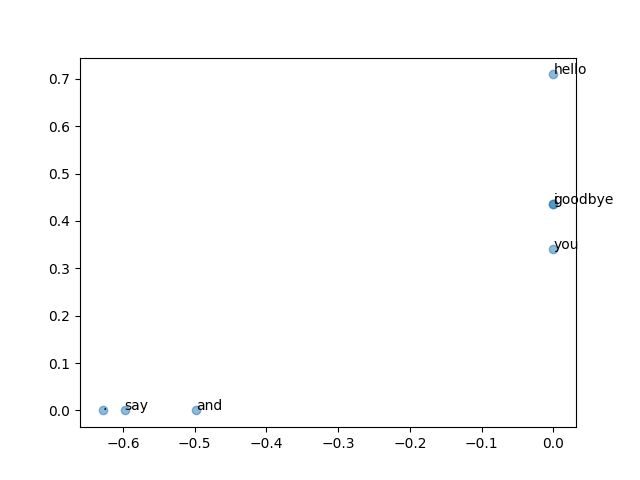

In [ ]:
(base) sanonanari@snnnrnoMacBook-Air deep-learning-from-scratch-2 % python ch02/show_ptb.py          
Downloading ptb.train.txt ... 
Done
corpus size: 929589
corpus[:30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

id_to_word[0]: aer
id_to_word[1]: banknote
id_to_word[2]: berlitz

word_to_id['car']: 3856
word_to_id['happy']: 4428
word_to_id['lexus']: 7426

In [ ]:
(base) sanonanari@snnnrnoMacBook-Air deep-learning-from-scratch-2 % python ch02/count_method_big.py  
counting  co-occurrence ...
calculating PPMI ...
1.0% done
2.0% done
略
[query] you
 i: 0.6934540271759033
 we: 0.5777190327644348
 anybody: 0.5470062494277954
 'll: 0.5367634296417236
 someone: 0.5007731914520264

[query] year
 month: 0.6574175953865051
 quarter: 0.644590437412262
 next: 0.6432541608810425
 last: 0.5974290370941162
 february: 0.5879477262496948

[query] car
 luxury: 0.6622846126556396
 auto: 0.6047461628913879
 vehicle: 0.5544455647468567
 corsica: 0.49139711260795593
 truck: 0.49094751477241516

[query] toyota
 motor: 0.7056629657745361
 motors: 0.6803943514823914
 nissan: 0.6391438245773315
 honda: 0.637651801109314
 mazda: 0.5354567170143127